In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rishikeshkonapure/hr-analytics-prediction/HR-Employee-Attrition.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/rishikeshkonapure/hr-analytics-prediction/HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
df['Over18'].unique()

array(['Y'], dtype=object)

In [7]:
df.drop(['EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance'],axis = 1, inplace = True)

In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'Gender',
       'HourlyRate', 'JobRole', 'MaritalStatus', 'OverTime', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [9]:
df = df.rename(columns = {
    'DailyRate' : 'Daily_wage',
    'DistanceFromHome' : 'Distance',
    'HourlyRate' : 'Hourly_wages'
})

In [10]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Daily_wage', 'Department',
       'Distance', 'Education', 'EducationField', 'Gender', 'Hourly_wages',
       'JobRole', 'MaritalStatus', 'OverTime', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [11]:
df.isnull().sum()

Age                        0
Attrition                  0
BusinessTravel             0
Daily_wage                 0
Department                 0
Distance                   0
Education                  0
EducationField             0
Gender                     0
Hourly_wages               0
JobRole                    0
MaritalStatus              0
OverTime                   0
YearsAtCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

In [12]:
df.describe()

,Age,Daily_wage,Distance,Education,Hourly_wages,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,65.891156,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,20.329428,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,30.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,48.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,66.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,83.750000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,100.000000,40.000000,18.000000,15.000000,17.000000


**Data Visualization** 

/tmp/ipykernel_55/1160710308.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'OverTime', data = df, palette = 'plasma')


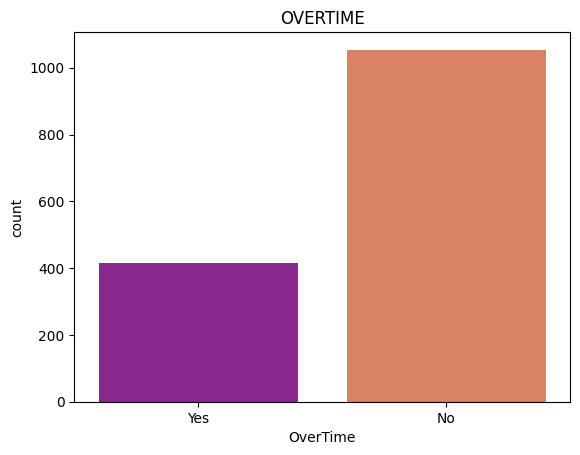

In [13]:
# plt.figure(figsize = (20,13))
sns.countplot(x = 'OverTime', data = df, palette = 'plasma')
plt.title("OVERTIME")
plt.show()

/tmp/ipykernel_55/1242164098.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'MaritalStatus', data = df, palette = 'crest')


Text(0.5, 1.0, 'MARTIAL STATUS')

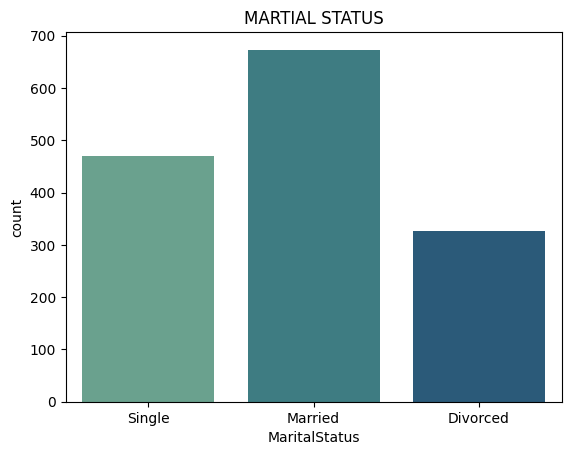

In [14]:
sns.countplot(x = 'MaritalStatus', data = df, palette = 'crest')
plt.title("MARTIAL STATUS")

/tmp/ipykernel_55/387975604.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'JobRole', data = df, palette = 'rocket')


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Sales Executive'),
  Text(1, 0, 'Research Scientist'),
  Text(2, 0, 'Laboratory Technician'),
  Text(3, 0, 'Manufacturing Director'),
  Text(4, 0, 'Healthcare Representative'),
  Text(5, 0, 'Manager'),
  Text(6, 0, 'Sales Representative'),
  Text(7, 0, 'Research Director'),
  Text(8, 0, 'Human Resources')])

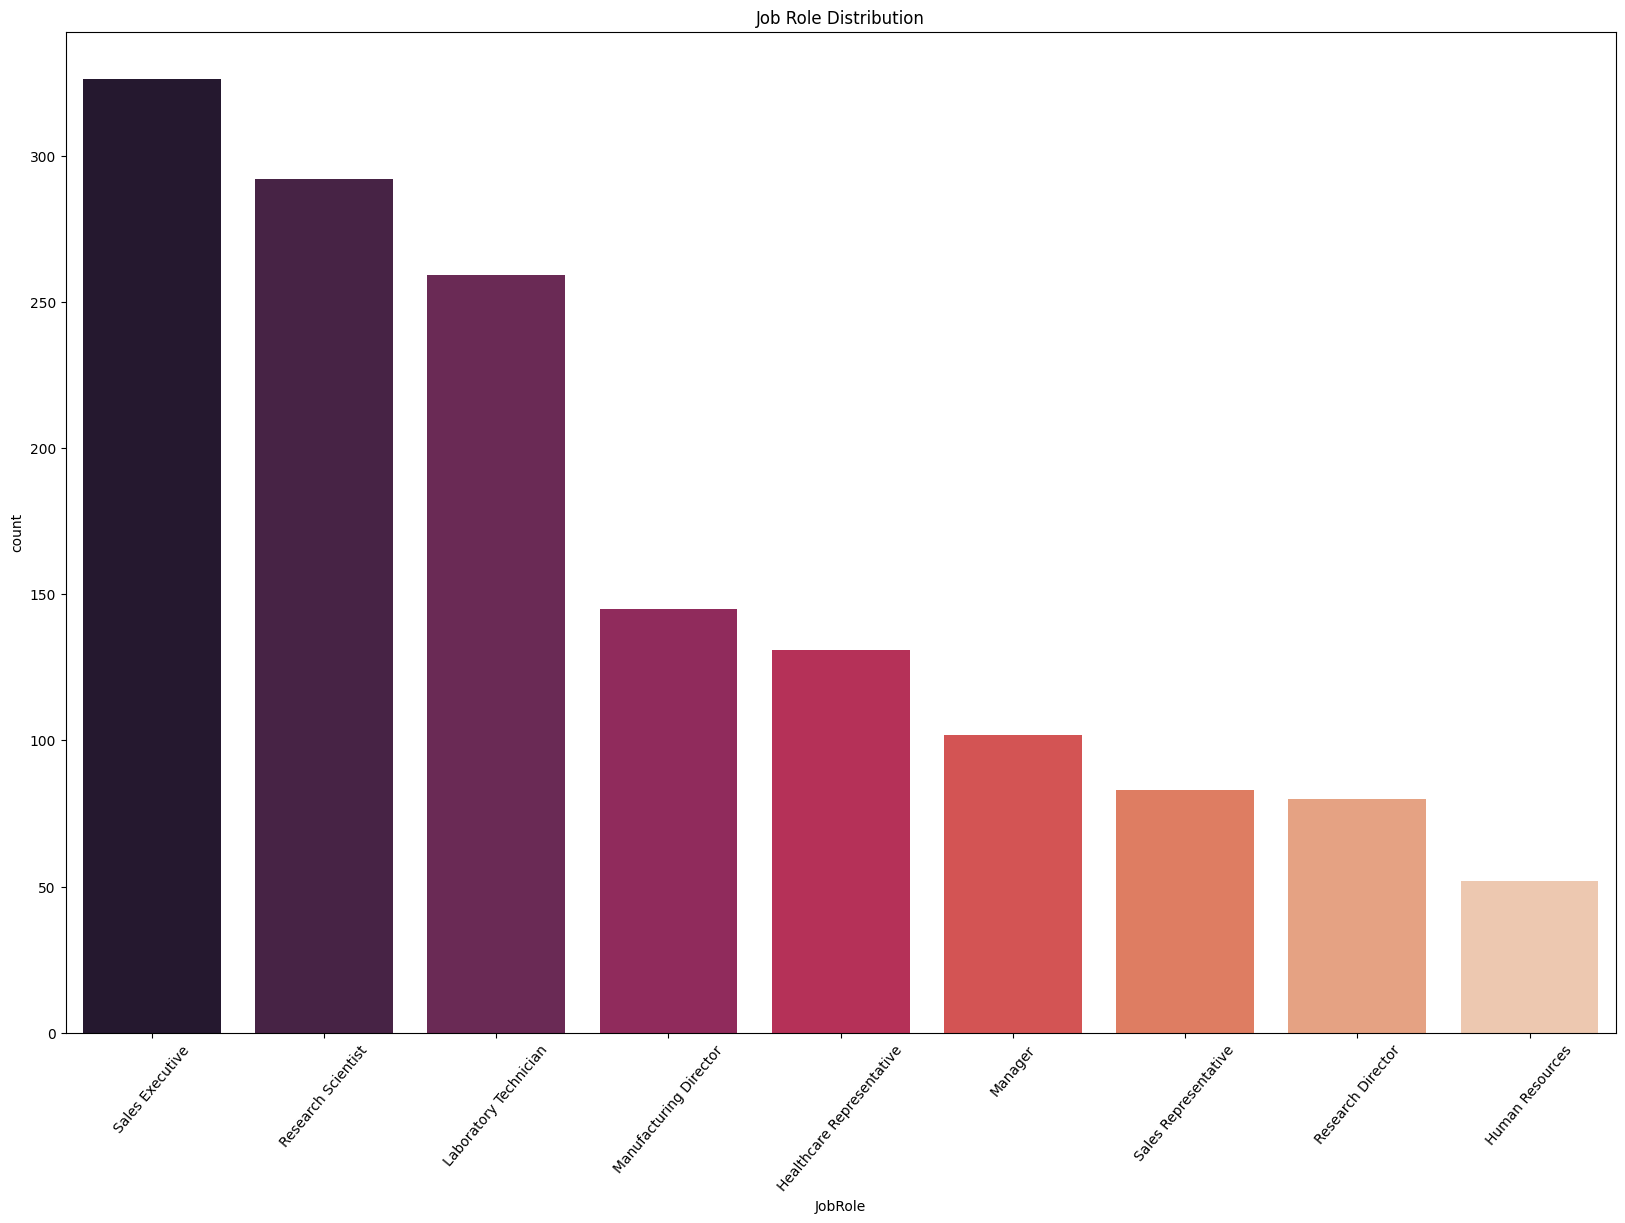

In [15]:
plt.figure(figsize = (20,13))
sns.countplot(x = 'JobRole', data = df, palette = 'rocket')
plt.title("Job Role Distribution")
plt.xticks(rotation = 50)

/tmp/ipykernel_55/2899815295.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Gender', data = df, palette = 'plasma')


Text(0.5, 1.0, 'Gender Distribution')

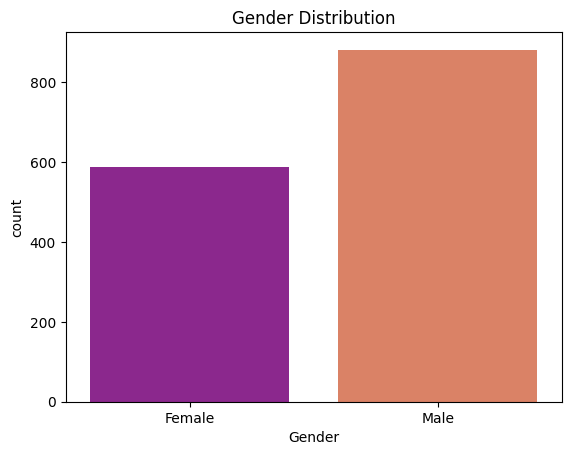

In [16]:
sns.countplot(x = 'Gender', data = df, palette = 'plasma')
plt.title("Gender Distribution")

/tmp/ipykernel_55/2598281025.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'EducationField', data = df, palette = 'crest')


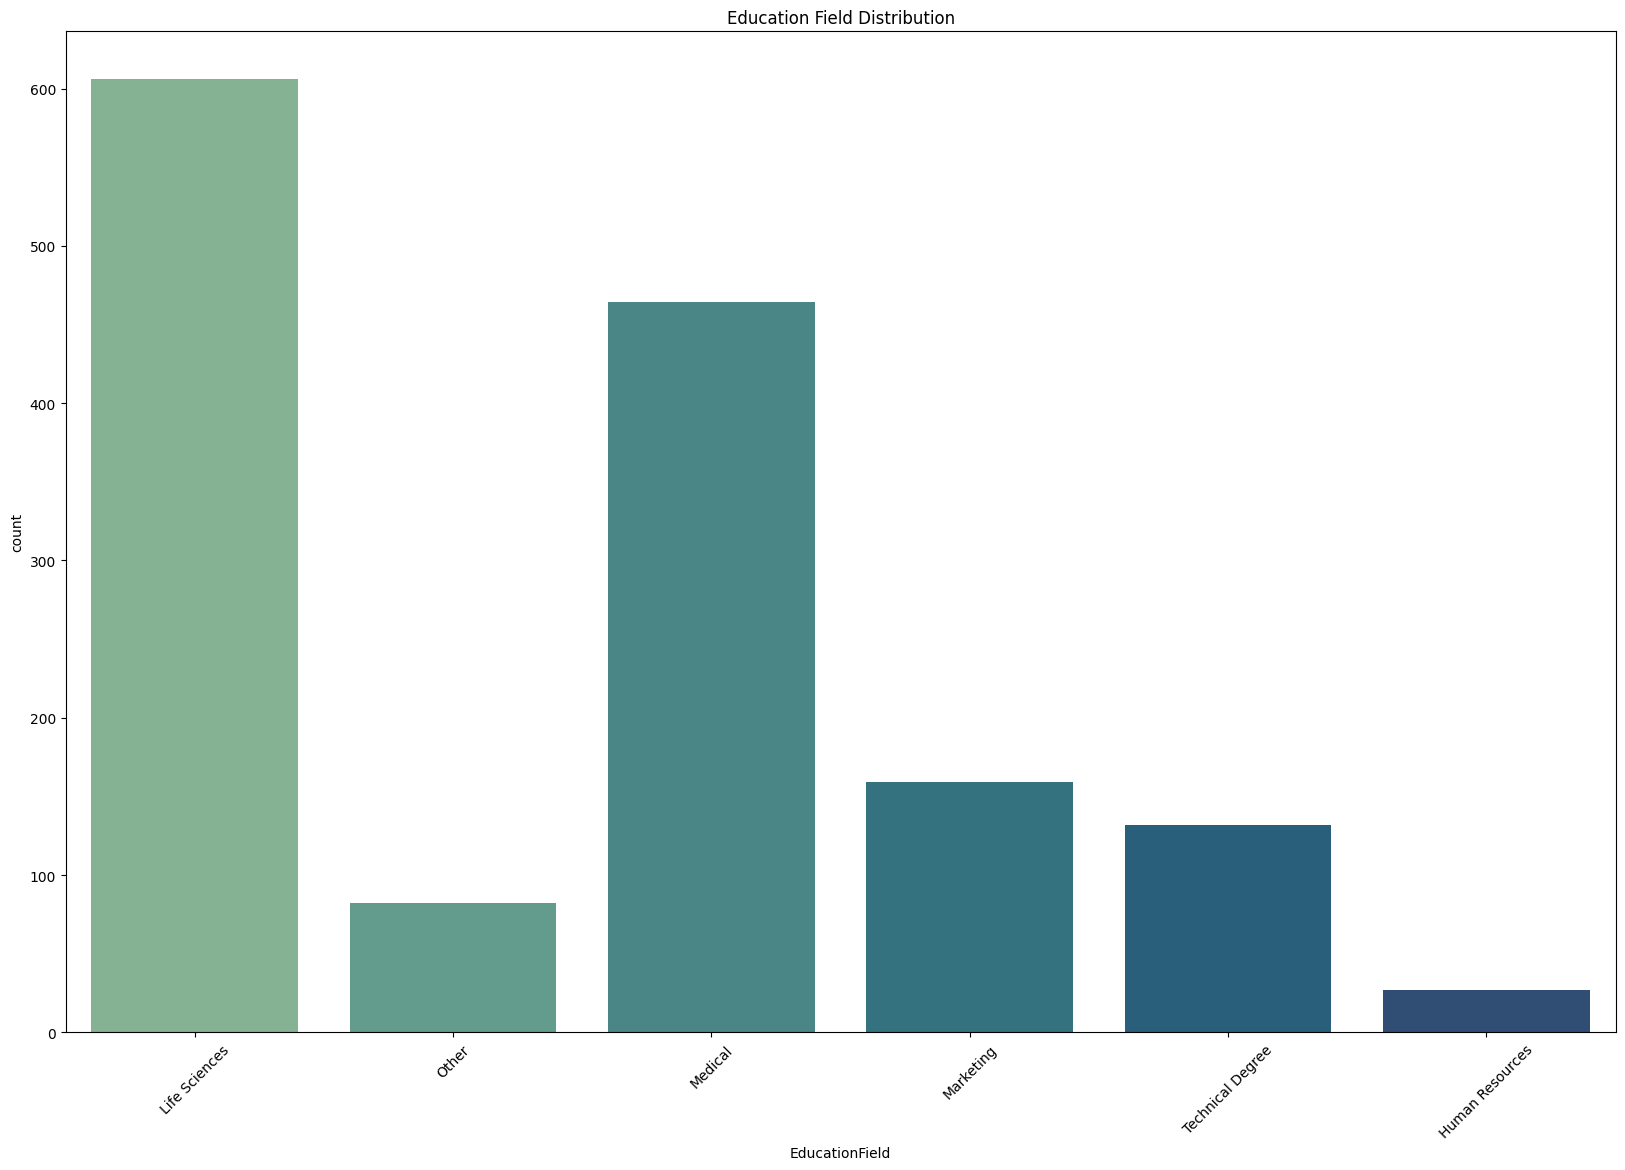

In [17]:
plt.figure(figsize = (20,13))
sns.countplot(x = 'EducationField', data = df, palette = 'crest')
plt.title('Education Field Distribution')
plt.xticks(rotation = 45)
plt.show()

/tmp/ipykernel_55/3529655051.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Department', data = df, palette = 'pastel')


Text(0.5, 1.0, 'Department Distribution')

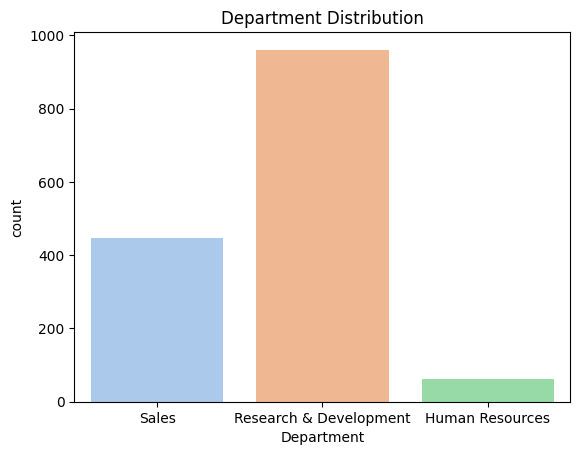

In [18]:
sns.countplot(x = 'Department', data = df, palette = 'pastel')
plt.title("Department Distribution")

/tmp/ipykernel_55/307048500.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'BusinessTravel', data = df, palette = 'pastel')


Text(0.5, 1.0, 'Business Travel Distribution')

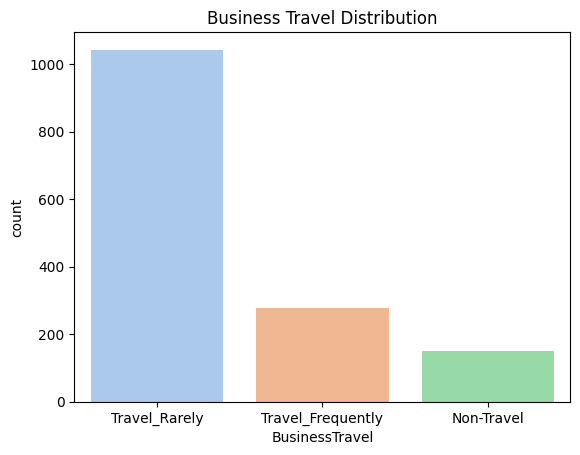

In [19]:
sns.countplot(x = 'BusinessTravel', data = df, palette = 'pastel')
plt.title("Business Travel Distribution")

/tmp/ipykernel_55/2449328737.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x = 'OverTime', y = 'Age', data = df, palette = 'plasma')


Text(0.5, 1.0, 'OverTime VS Age')

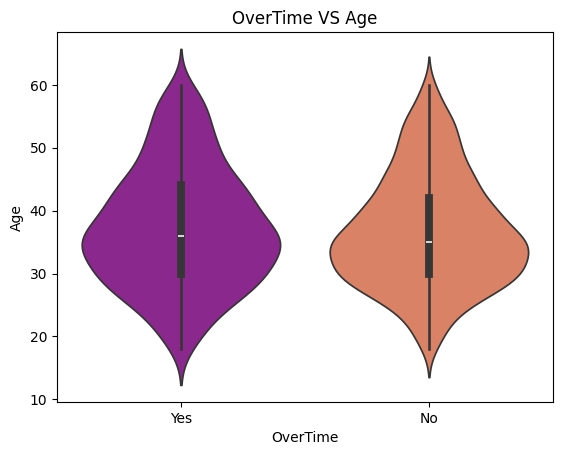

In [20]:
sns.violinplot(x = 'OverTime', y = 'Age', data = df, palette = 'plasma')
plt.title("OverTime VS Age")

In [21]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Daily_wage', 'Department',
       'Distance', 'Education', 'EducationField', 'Gender', 'Hourly_wages',
       'JobRole', 'MaritalStatus', 'OverTime', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

/tmp/ipykernel_55/2983794769.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'YearsAtCompany', data = df, palette = 'plasma')


<Axes: xlabel='YearsAtCompany', ylabel='count'>

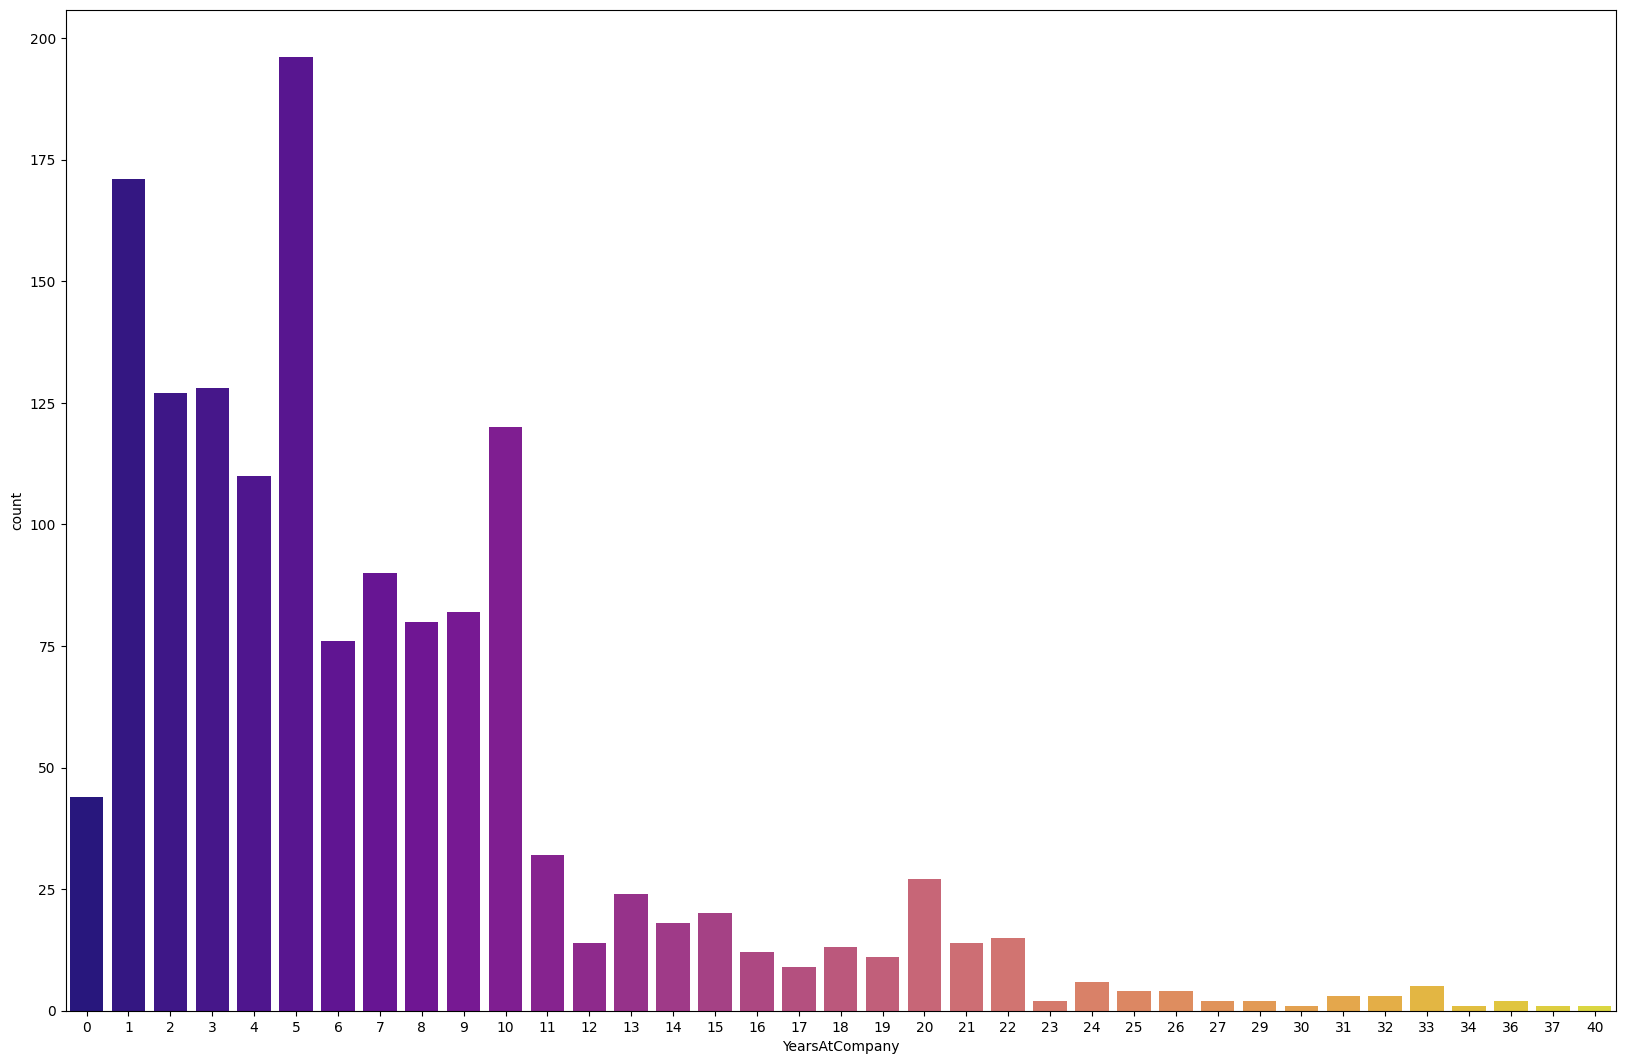

In [22]:
plt.figure(figsize = (20,13))
sns.countplot(x = 'YearsAtCompany', data = df, palette = 'plasma')

/tmp/ipykernel_55/2429664398.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Age', data = df, palette = 'Set2')


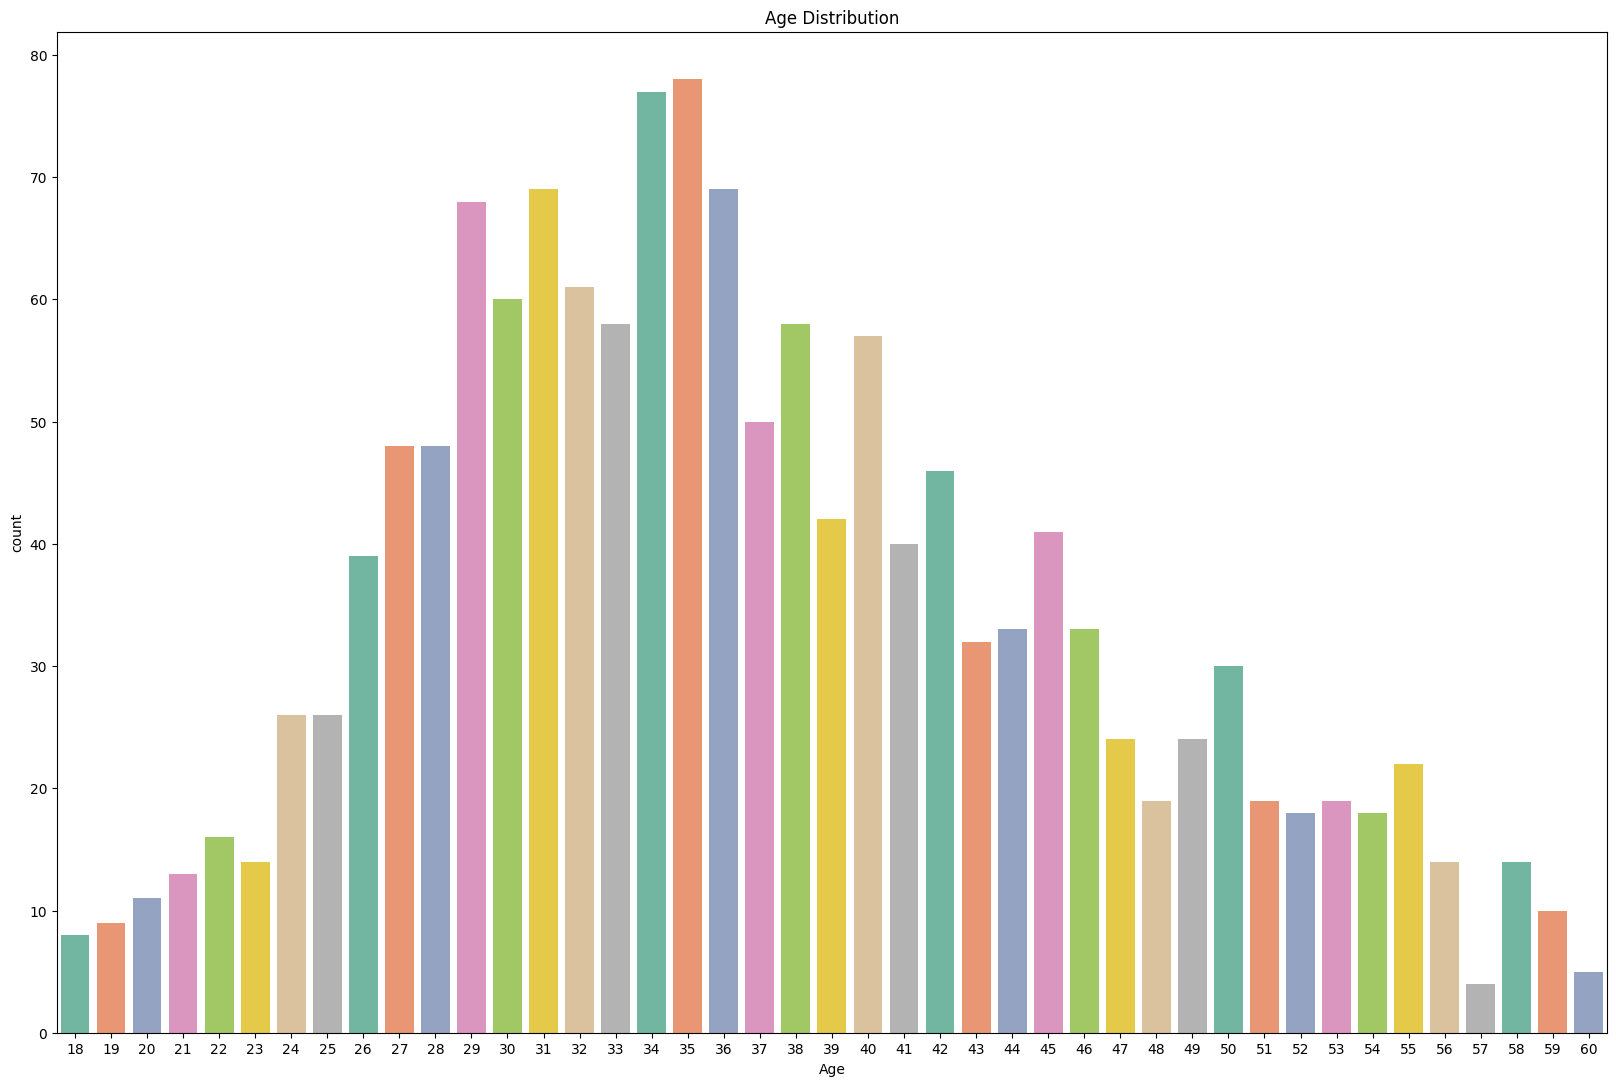

In [23]:
plt.figure(figsize = (20,13))
sns.countplot(x = 'Age', data = df, palette = 'Set2')
plt.title("Age Distribution")
plt.show()

In [24]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Daily_wage', 'Department',
       'Distance', 'Education', 'EducationField', 'Gender', 'Hourly_wages',
       'JobRole', 'MaritalStatus', 'OverTime', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   BusinessTravel           1470 non-null   object
 3   Daily_wage               1470 non-null   int64 
 4   Department               1470 non-null   object
 5   Distance                 1470 non-null   int64 
 6   Education                1470 non-null   int64 
 7   EducationField           1470 non-null   object
 8   Gender                   1470 non-null   object
 9   Hourly_wages             1470 non-null   int64 
 10  JobRole                  1470 non-null   object
 11  MaritalStatus            1470 non-null   object
 12  OverTime                 1470 non-null   object
 13  YearsAtCompany           1470 non-null   int64 
 14  YearsInCurrentRole       1470 non-null  

/tmp/ipykernel_55/1775278438.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'JobRole', y = 'YearsWithCurrManager', data = df, palette = 'Set2')


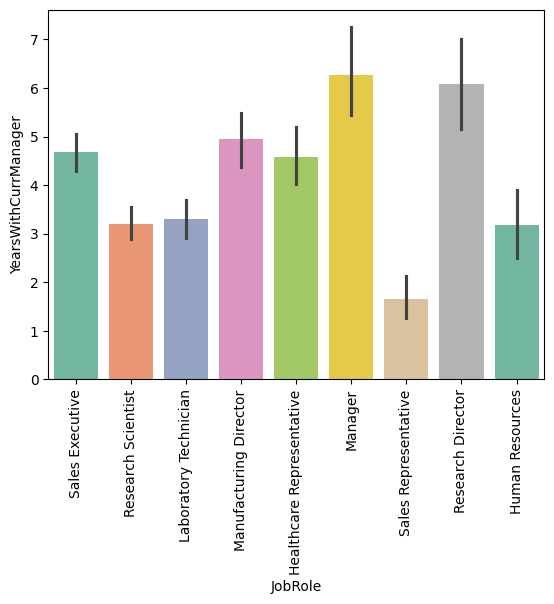

In [26]:
# plt.figure(figsize = (30,30))
sns.barplot(x = 'JobRole', y = 'YearsWithCurrManager', data = df, palette = 'Set2')
plt.xticks(rotation = 90)
plt.show()

/tmp/ipykernel_55/3919288546.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'JobRole', y = 'YearsSinceLastPromotion', data = df, palette = 'crest')


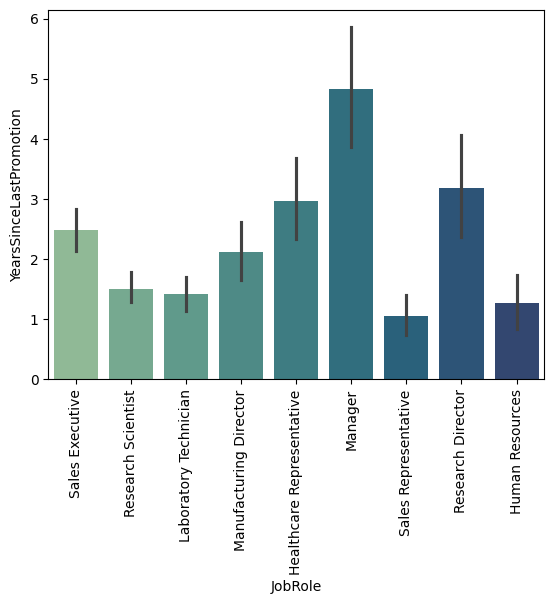

In [27]:
sns.barplot(x = 'JobRole', y = 'YearsSinceLastPromotion', data = df, palette = 'crest')
plt.xticks(rotation = 90)
plt.show()

/tmp/ipykernel_55/2465781967.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'JobRole', y = 'YearsInCurrentRole', data = df, palette = 'Set3')


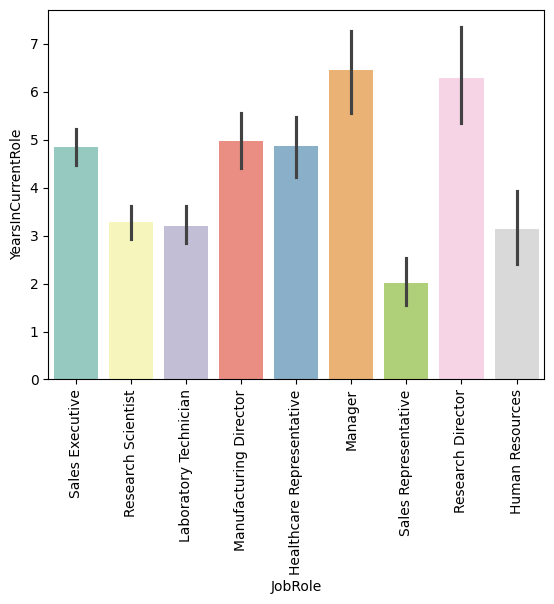

In [28]:
sns.barplot(x = 'JobRole', y = 'YearsInCurrentRole', data = df, palette = 'Set3')
plt.xticks(rotation = 90)
plt.show()

In [29]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Daily_wage', 'Department',
       'Distance', 'Education', 'EducationField', 'Gender', 'Hourly_wages',
       'JobRole', 'MaritalStatus', 'OverTime', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   BusinessTravel           1470 non-null   object
 3   Daily_wage               1470 non-null   int64 
 4   Department               1470 non-null   object
 5   Distance                 1470 non-null   int64 
 6   Education                1470 non-null   int64 
 7   EducationField           1470 non-null   object
 8   Gender                   1470 non-null   object
 9   Hourly_wages             1470 non-null   int64 
 10  JobRole                  1470 non-null   object
 11  MaritalStatus            1470 non-null   object
 12  OverTime                 1470 non-null   object
 13  YearsAtCompany           1470 non-null   int64 
 14  YearsInCurrentRole       1470 non-null  

In [31]:
df

,Age,Attrition,BusinessTravel,Daily_wage,Department,Distance,Education,EducationField,Gender,Hourly_wages,JobRole,MaritalStatus,OverTime,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,Female,94,Sales Executive,Single,Yes,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,Male,61,Research Scientist,Married,No,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,Male,92,Laboratory Technician,Single,Yes,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,Female,56,Research Scientist,Married,Yes,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,Male,40,Laboratory Technician,Married,No,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,Male,41,Laboratory Technician,Married,No,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,Male,42,Healthcare Representative,Married,No,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,Male,87,Manufacturing Director,Married,Yes,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,Male,63,Sales Executive,Married,No,9,6,0,8


/tmp/ipykernel_55/932235995.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'JobRole', y = 'Daily_wage', data = df, palette = 'Paired')


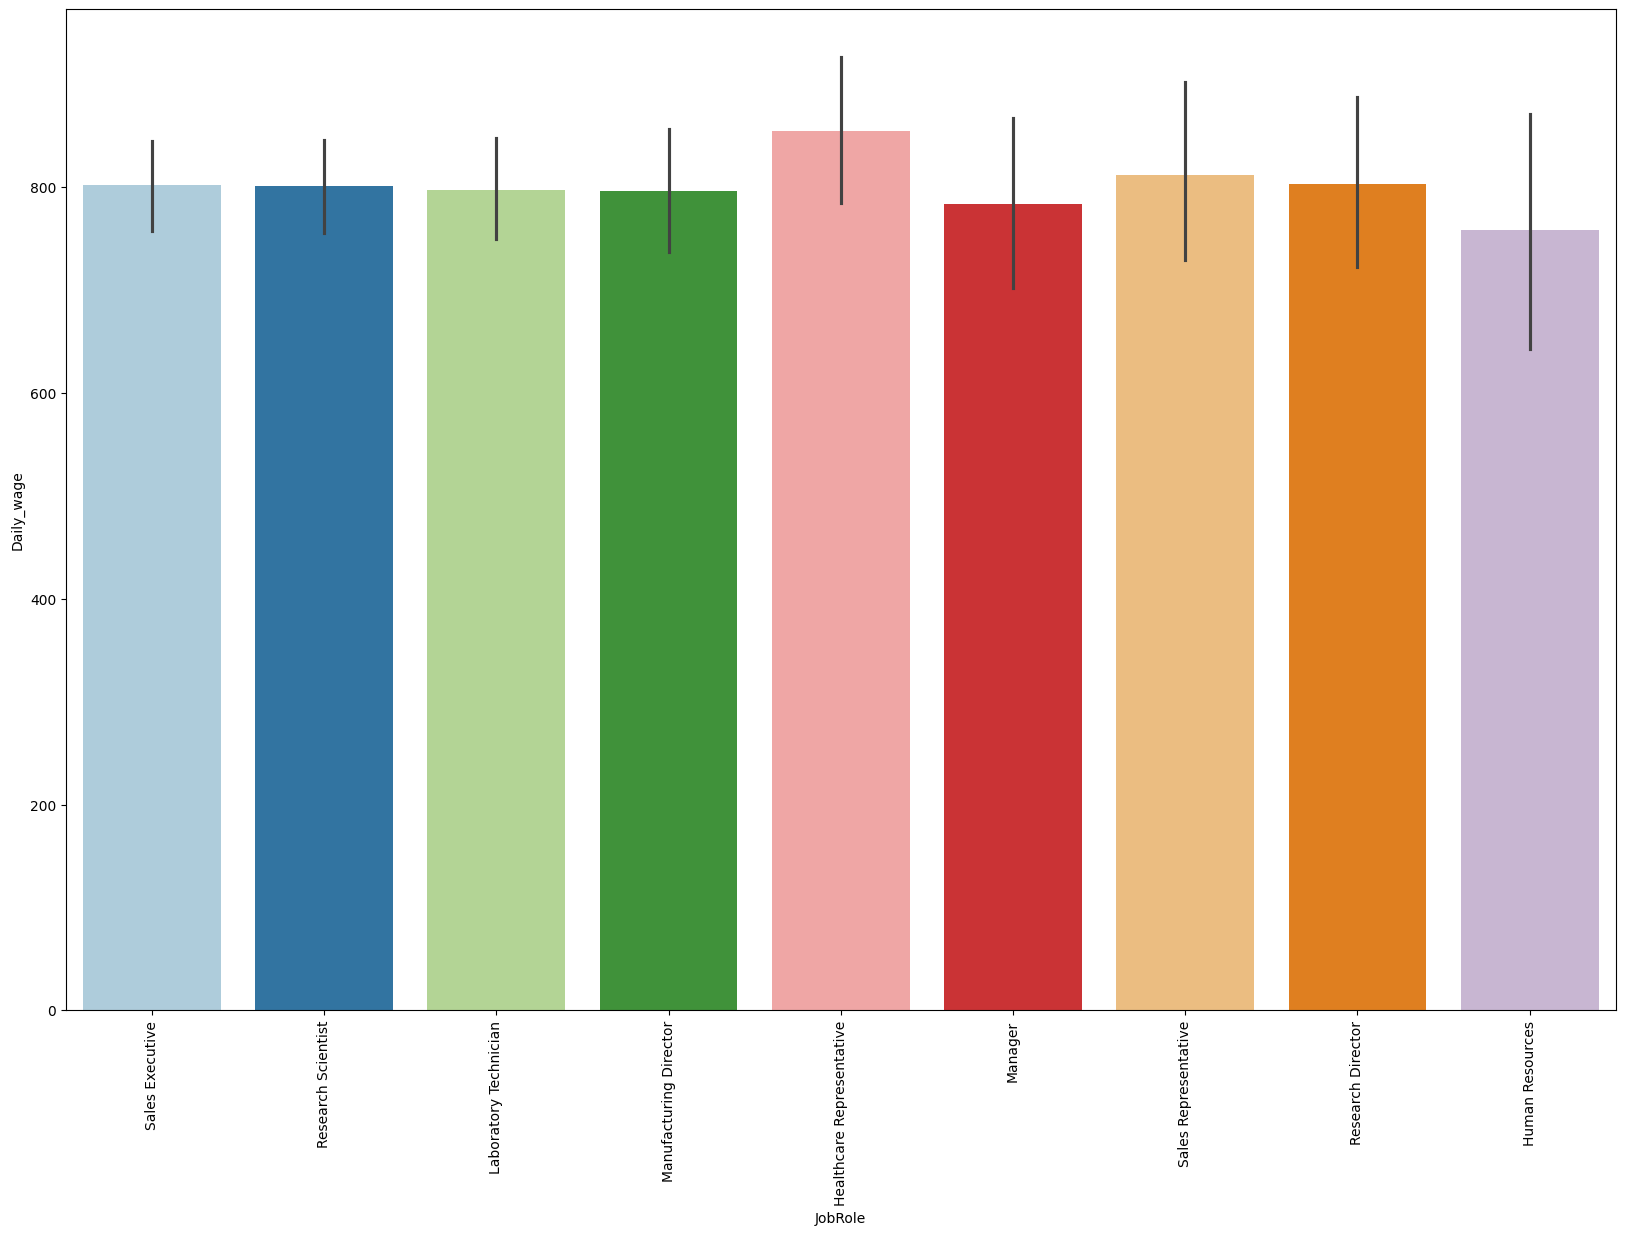

In [42]:
plt.figure(figsize = (20,13))
sns.barplot(x = 'JobRole', y = 'Daily_wage', data = df, palette = 'Paired')
plt.xticks(rotation = 90)
plt.show()

/tmp/ipykernel_55/1363062342.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'JobRole', y = 'Hourly_wages', data = df, palette = 'plasma')


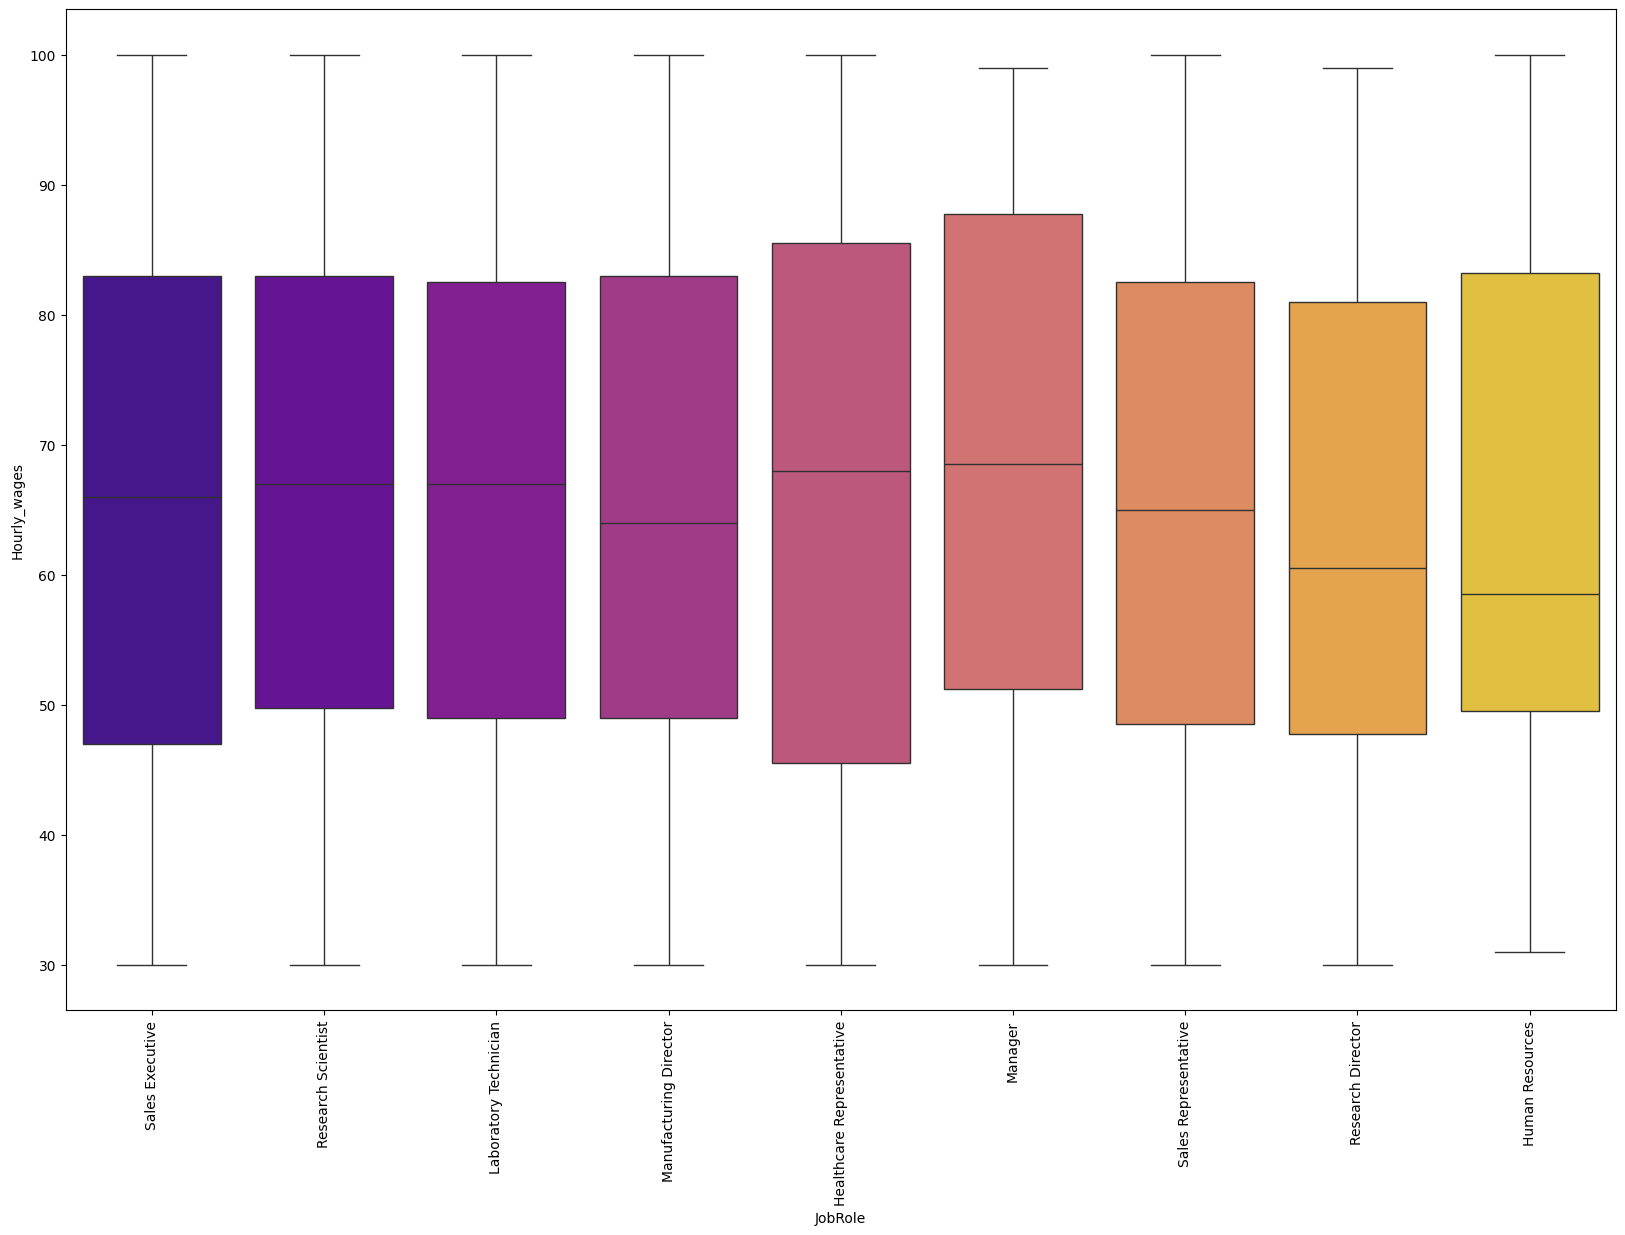

In [46]:
plt.figure(figsize = (20,13))
sns.boxplot(x = 'JobRole', y = 'Hourly_wages', data = df, palette = 'plasma')
plt.xticks(rotation = 90)
plt.show()

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   BusinessTravel           1470 non-null   object
 3   Daily_wage               1470 non-null   int64 
 4   Department               1470 non-null   object
 5   Distance                 1470 non-null   int64 
 6   Education                1470 non-null   int64 
 7   EducationField           1470 non-null   object
 8   Gender                   1470 non-null   object
 9   Hourly_wages             1470 non-null   int64 
 10  JobRole                  1470 non-null   object
 11  MaritalStatus            1470 non-null   object
 12  OverTime                 1470 non-null   object
 13  YearsAtCompany           1470 non-null   int64 
 14  YearsInCurrentRole       1470 non-null  